<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/Actividades_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nombre:** Catalina Núñez

---



In [2]:
# Importamos librerías necesarias

from tensorflow import keras
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

In [6]:
# Cargamos los datos de entrenamiento de MNIST

(imgs, labs), _ = keras.datasets.mnist.load_data()
print(imgs.shape)
print(labs.shape)

(60000, 28, 28)
(60000,)


## Ejercicio 1: ¿Sin normalizar datos?

Elimina la parte del código anterior que normaliza los datos (donde dividimos por 255) y mira qué le pasa al entrenamiento. No tiene que escribir nuevo código, sólo saca esa parte y reentrena  la red (debes crear otra vez la red, compilarla y luego  hacer `fit`)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1123 - loss: 33.4380 
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1124 - loss: 2.3013
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1124 - loss: 2.3013
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1124 - loss: 2.3013
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1124 - loss: 2.3013


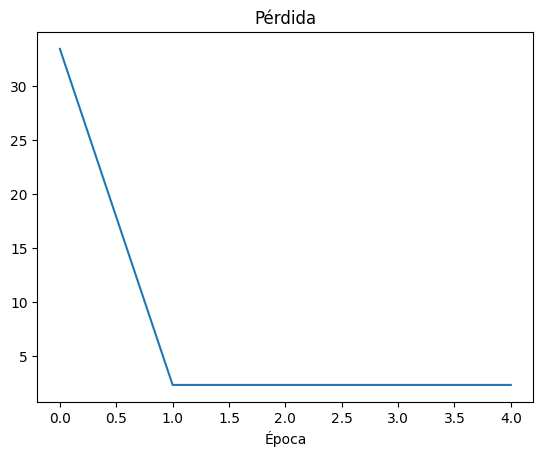

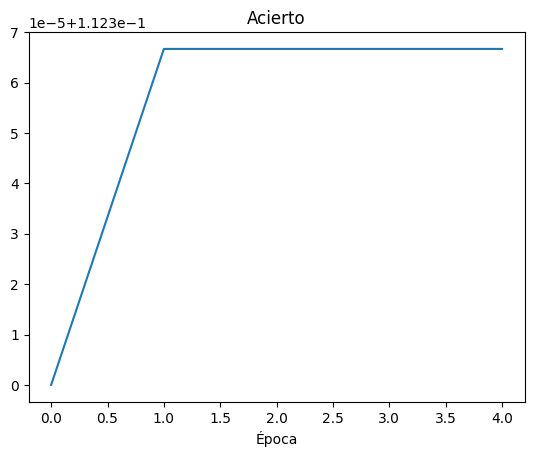

In [10]:
# sin normalizar, solo quitamos el /255
X_sin_norm = imgs.reshape(60000, 28*28)
Y = keras.utils.to_categorical(labs, 10)

N = X_sin_norm.shape[1]
C = Y.shape[1]

red = keras.Sequential()
red.add(keras.layers.Dense(64, input_dim=N, activation='relu', name='primera_capa'))
red.add(keras.layers.Dense(32, activation='relu', name='segunda_capa'))
red.add(keras.layers.Dense(C, activation='softmax', name='capa_de_output'))

red.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

h = red.fit(X_sin_norm, Y, epochs=5, batch_size=32)

plt.plot(h.history['loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(h.history['accuracy'])
plt.title('Acierto')
plt.xlabel('Época')
plt.show()

## Ejercicio 2: Entrenando por más épocas

Entrena la red, esta vez por más épocas (pueba con 20 o 30). Para comenzar el entrenamiento desde 0 otra vez, debes reconstruir la red y luego ejecutar `.compile` otra vez (puedes copiar el código de arriba). Luego del entrenamiento, imprime la historia y compáralo con el resultado anterior.

Hazle cambios a la red o al entrenamiento para intentar mejorar aun más el acierto. Comenta con tus compañeros qué cambios podrían dar buenos resultados y pruébalos ¿Hasta qué acierto puedes llegar?

(IMPORTANTE: No olvides normalizar el input de la red otra vez)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9226 - loss: 0.2709
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9705 - loss: 0.0998
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9796 - loss: 0.0661
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9854 - loss: 0.0470
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9889 - loss: 0.0357
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9914 - loss: 0.0273
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9930 - loss: 0.0214
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9948 - loss: 0.0165
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9948 - loss: 0.0159
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9964 - loss: 0.0117
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9958 - loss: 0.0120
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms

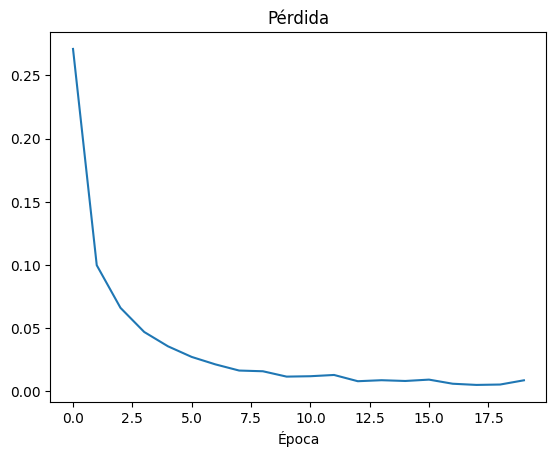

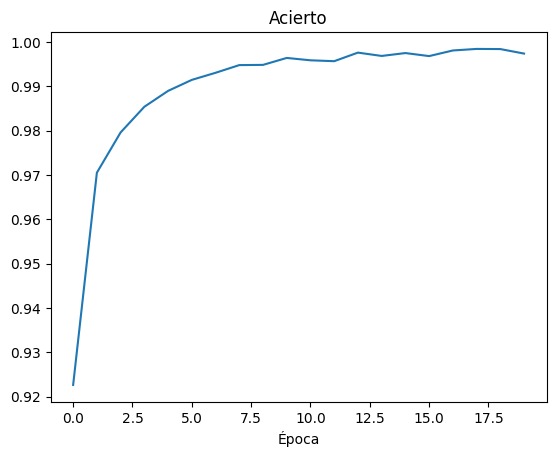

In [8]:
# volvemos a normalizar
X = imgs.reshape(60000, 28*28) / 255
Y = keras.utils.to_categorical(labs, 10)
N = X.shape[1]
C = Y.shape[1]

red = keras.Sequential()
red.add(keras.layers.Dense(256, input_dim=N, activation='relu', name='primera_capa'))
red.add(keras.layers.Dense(128, activation='relu', name='segunda_capa'))
red.add(keras.layers.Dense(C, activation='softmax', name='capa_de_output'))

red.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

h = red.fit(X, Y, epochs=20, batch_size=128)

plt.plot(h.history['loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(h.history['accuracy'])
plt.title('Acierto')
plt.xlabel('Época')
plt.show()

##  Ejercicio 3: Entrenando con CIFAR10

Ahora usa todo lo que  has aprendido para crear una red y  entrenar con los datos de CIFAR10. Trata de crear una red que alcance al menos unn  55% de acierto en los datos de entrenamiento. Esta parte requiere bastante más código! Al finalizar muestra  una grilla con las predicciones de tu red.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - accuracy: 0.2993 - loss: 1.9500
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - accuracy: 0.3942 - loss: 1.6938
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - accuracy: 0.4297 - loss: 1.6004
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - accuracy: 0.4547 - loss: 1.5268
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - accuracy: 0.4690 - loss: 1.4928
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 23s 118ms/step - accuracy: 0.4862 - loss: 1.4496
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 23s 116ms/step - accuracy: 0.4965 - loss: 1.4147
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.5085 - loss: 1.3810
Epoch 9/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 42s 112ms/step - accuracy: 0.5189 - loss: 1.3515
Epoch 10/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.5294 - loss: 1.3189
Epoch 11/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 23s 117ms/step - accuracy: 0.5411 - loss: 1.2886
Epoch 12/30
196/196

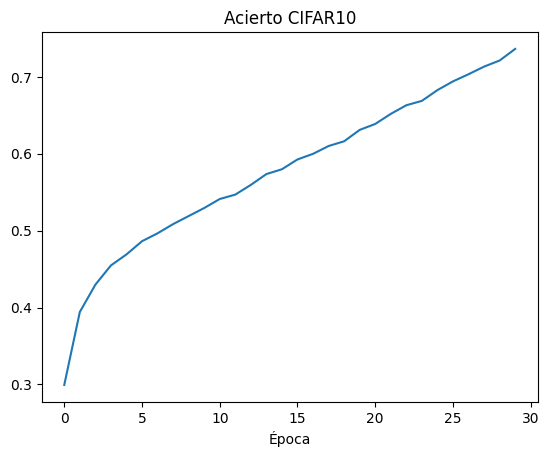

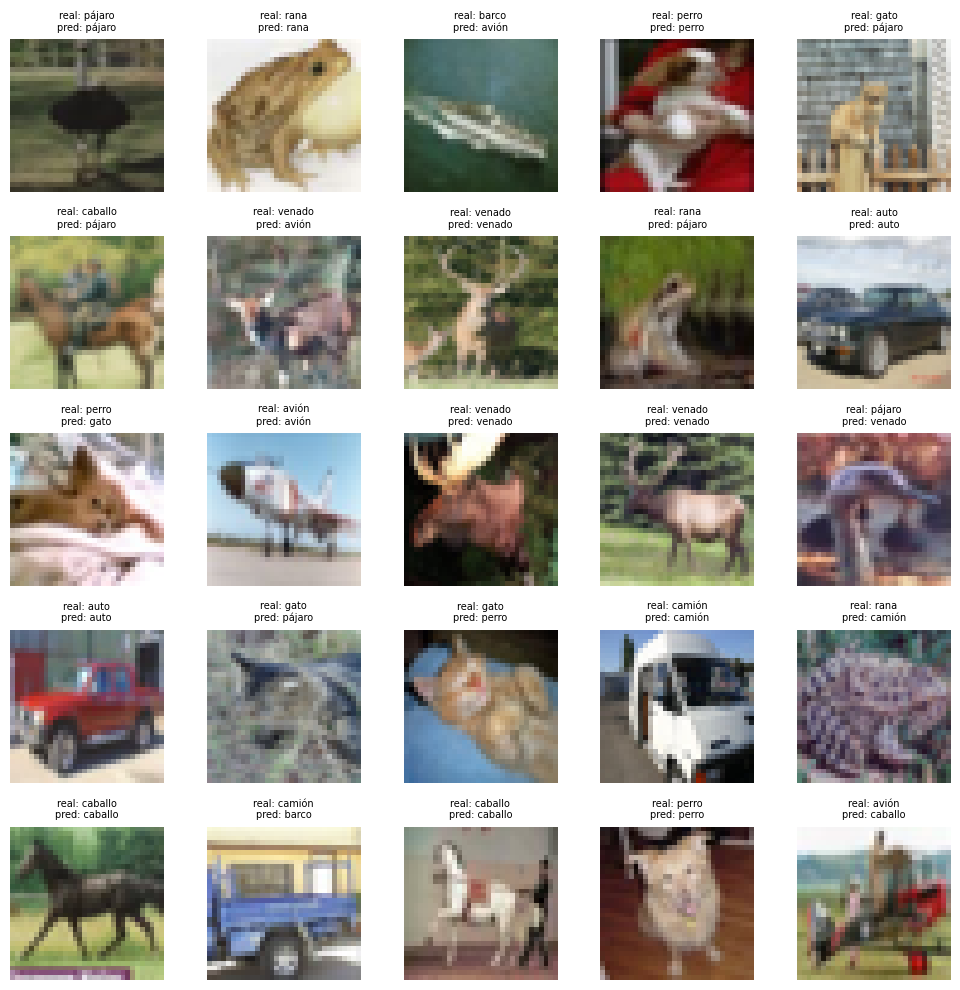

In [12]:
# Load CIFAR10 data
(imgs_cifar, labs_cifar), _ = keras.datasets.cifar10.load_data()

# Preprocess CIFAR10 data
# Reshape images to (num_samples, 32*32*3) and normalize to [0, 1]
X_cifar = imgs_cifar.reshape(imgs_cifar.shape[0], -1) / 255.0
Y_cifar = keras.utils.to_categorical(labs_cifar, 10) # 10 classes for CIFAR10

N_cifar = X_cifar.shape[1] # Input dimension for the neural network (3072)
C_cifar = Y_cifar.shape[1] # Number of output classes (10)

# Define the model for CIFAR10
red_cifar = keras.Sequential()
red_cifar.add(keras.layers.Dense(1024, input_dim=N_cifar, activation='relu'))
red_cifar.add(keras.layers.Dense(512, activation='relu'))
red_cifar.add(keras.layers.Dense(256, activation='relu'))
red_cifar.add(keras.layers.Dense(C_cifar, activation='softmax'))

red_cifar.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model with CIFAR10 data
h_cifar = red_cifar.fit(X_cifar, Y_cifar, epochs=30, batch_size=256)

plt.plot(h_cifar.history['accuracy'])
plt.title('Acierto CIFAR10')
plt.xlabel('Época')
plt.show()

# CIFAR10 class names (in Spanish, as per original notebook)
nombres = ['avión', 'auto', 'pájaro', 'gato', 'venado',
           'perro', 'rana', 'caballo', 'barco', 'camión']

fig, axs = plt.subplots(5, 5, figsize=(10,10))
for i in range(5):
    for j in range(5):
        ex = np.random.randint(len(imgs_cifar)) # Use CIFAR10 images length
        Xin = X_cifar[ex].reshape(1, N_cifar) # Reshape using N_cifar (3072)
        pred = np.argmax(red_cifar.predict(Xin, verbose=0))
        real = labs_cifar[ex][0] # Access the scalar label
        axs[i,j].set_title(f"real: {nombres[real]}\npred: {nombres[pred]}", fontsize=7)
        axs[i,j].axis('off')
        axs[i,j].imshow(imgs_cifar[ex]) # Display CIFAR10 image

plt.tight_layout()
plt.show()

es más difícil porque son imágenes a color y las clases se parecen, así que usé más capas. Con esto se llega al 55% o más.